# Banc d'essai -- `PixelTraceSource.normalized_signal`

Prend UNE video recalee (meme arborescence que `compute_one_cycle_pixel_svd.py`)
et affiche, etape par etape, ce que fait -- et ce que devrait faire -- la
normalisation d'intensite des traces pixel
(`motion/pulsation/traces/pixel.py`).

Le point de depart est `PixelTraceSource.raw_signal()` : une matrice `(T, N)`
d'intensites, une colonne par pixel/super-pixel de la ROI, concatenee sur les
echelles de bloc `block_sizes`. Deux normalisations distinctes sont possibles
sur cette matrice, et le code actuel de `normalized_signal` melange les deux :

| axe | operation | ce que ca enleve |
|---|---|---|
| `axis=0` (temps, **par trace**) | centrage-reduction (z-score) | l'heterogeneite de brillance ENTRE pixels |
| `axis=1` (traces, **par frame**) | division par la moyenne spatiale | la derive de gain/illumination COMMUNE a tous les pixels |

Le docstring annonce la premiere (*"zero mean, unit variance"*), le corps de la
methode calcule la seconde (`np.nanmean(sig, axis=1)`). Ce notebook les separe
pour qu'on puisse decider laquelle on veut -- et surtout mesurer le risque de
la seconde : la ROI etant entierement DANS la choroide, la pulsation
choroidienne est largement en phase d'un pixel a l'autre, donc la moyenne
spatiale par frame **contient le signal cardiaque**. Diviser par elle le
soustrait.

## Plan

0. signal brut `raw_signal()` -- ROI, traces, ordres de grandeur
1. statistiques **par trace** (`axis=0`) : la carte de brillance moyenne
2. statistique **par frame** (`axis=1`) : le diviseur du code actuel, et son spectre
3. variante A -- normalisation par frame (ce que fait le code aujourd'hui)
4. variante B -- z-score par trace (ce que dit le docstring)
5. variante C -- les deux enchainees
6. recapitulatif spectral des 4 variantes
7. effet en aval : SVD + puissance dans la bande cardiaque
8. etat actuel de `normalized_signal()` (appel reel)

In [28]:
from pathlib import Path
import csv

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from ocularrigidity.motion.pulsation import (
    CardiacBand,
    PixelTraceConfig,
    PixelTraceSource,
)
from ocularrigidity.motion.pulsation.rate import lomb_scargle_power
from ocularrigidity.motion.projection._1d import project_into_separable_components
from ocularrigidity.motion.video_timeline_aligner import VideoTimelineAligner
from ocularrigidity.scripts.one_cycle.astronauts import _prepared_registrator
from ocularrigidity.scripts.registration.astronauts import load_ordered_oct_series

# --- La condition inspectee (memes chemins que compute_one_cycle_pixel_svd.py) ---
PATH_GENERAL = Path("E:/SANSORI")            # arborescence brute (horodatages, HR)
SEGVAR_ROOT = Path("E:/NASA_Rigidity/SegmentationVariations")
MASK_VARIANT = "model1_scale_1.0"
ASTRO = "01_210713001"
MOMENT = "210713001before_rigidity"
CONDITION = "210713001before_rigidity_OD"

# --- PixelTraceConfig teste (defauts du package, explicites ici) ---
COL_FRAC = (1 / 4, 3 / 4)
ROW_FRAC = (0.0, 0.5)
BLOCK_SIZES = (1, 3, 5)

# --- Bande cardiaque : large pour le DIAGNOSTIC (on veut voir les harmoniques
# et la derive basse frequence), etroite (BAND_FRAC autour de la HR mesuree)
# pour le SCORE, comme dans le script. ---
DIAG_BPM_RANGE = (20.0, 240.0)
BAND_FRAC = 0.1

# --- Sous-echantillonnage : N vaut 10^4-10^5 colonnes, on n'en trace qu'une
# poignee et on ne calcule les periodogrammes que sur un echantillon. ---
N_TRACES_PLOT = 6
N_TRACES_SPEC = 400
RNG = np.random.default_rng(0)

N_SVD_COMPONENTS = 20

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", DEVICE)

device = cuda


In [29]:
# Helpers de chemins/horodatages -- identiques a compute_one_cycle_pixel_svd.py.
# (SegmentationVariations n'ecrit pas de timestamp.txt : les horodatages sont
# recalcules depuis l'export XML Spectralis.)


def find_raw_dir(condition_dir: Path):
    for name in ("RawImages", "RawData"):
        d = condition_dir / name
        if d.is_dir():
            return d
    return None


def raw_timestamps_us(raw_dir: Path) -> np.ndarray:
    series = load_ordered_oct_series(raw_dir)
    return np.array(
        [int(round(s.acquisition_time.seconds_of_day * 1e6)) for s in series],
        dtype=np.int64,
    )


def read_hr(path_condi: Path) -> float:
    path_heartbeat = path_condi / "Data Files" / "visit_data.csv"
    if not path_heartbeat.exists():
        return float("nan")
    df = pd.read_csv(path_heartbeat, quoting=csv.QUOTE_NONE)
    return float(np.nanmean(pd.to_numeric(df["HR"], errors="coerce")))

In [30]:
condi_dir = PATH_GENERAL / ASTRO / MOMENT / CONDITION
variant_root = SEGVAR_ROOT / MASK_VARIANT
frames_path = variant_root / "registered_frames" / ASTRO / MOMENT / CONDITION / "cube.mp4"
mask_path = variant_root / "registered_masks" / ASTRO / MOMENT / CONDITION / "mask.npz"

for p in (condi_dir, frames_path, mask_path):
    if not p.exists():
        raise FileNotFoundError(p)

registrator = _prepared_registrator(frames_path, mask_path, DEVICE, verbose=False)
raw_dir = find_raw_dir(condi_dir)
if raw_dir is None:
    raise FileNotFoundError(f"RawImages/RawData absent : {condi_dir}")
ts_us = raw_timestamps_us(raw_dir)

n_frames = registrator.registered_frames.shape[0]
if n_frames != ts_us.size:
    raise ValueError(f"frames ({n_frames}) != horodatages ({ts_us.size})")

aligner = VideoTimelineAligner(registrator, ts_us)
t = aligner.timestamps_seconds          # (T,) horodatages reels, NON uniformes
hr = read_hr(condi_dir)
band = CardiacBand(
    expected_bpm=float(hr) if np.isfinite(hr) else None,
    expected_bpm_band_frac=BAND_FRAC,
)

print(f"{ASTRO} / {MOMENT} / {CONDITION}  (variante = {MASK_VARIANT})")
print(f"video     : {registrator.registered_frames.shape} {registrator.registered_frames.dtype}")
print(f"duree     : {t[-1] - t[0]:.2f} s, fs mediane = {aligner.fs:.2f} Hz")
print(f"HR mesuree: {hr:.1f} BPM" if np.isfinite(hr) else "HR mesuree: <absente>")

01_210713001 / 210713001before_rigidity / 210713001before_rigidity_OD  (variante = model1_scale_1.0)
video     : (401, 496, 768) uint8
duree     : 27.30 s, fs mediane = 17.86 Hz
HR mesuree: 63.0 BPM


## 0. Signal brut : `raw_signal()`

`raw_signal()` renvoie `(T, N)` : une colonne par pixel de la ROI (intersection
du masque dans le temps, restreinte par `col_frac`/`row_frac`) a l'echelle
`block=1`, PLUS une colonne par super-pixel median a chaque echelle superieure.
Aucun NaN ici (par construction, la ROI est valide sur toutes les frames), donc
`nanmean` et `mean` sont equivalents -- on garde `nanmean` pour coller au code
de `normalized_signal`.

In [31]:
source = PixelTraceSource(
    registrator,
    aligner,
    PixelTraceConfig(
        band=band,
        col_frac=COL_FRAC,
        row_frac=ROW_FRAC,
        block_sizes=BLOCK_SIZES,
        verbose=True,
    ),
)

sig0 = source.raw_signal().astype(np.float32)   # (T, N)
sig0n = source.normalized_signal().astype(np.float32)   # (T, N)
scale = source.scale_of_trace                    # (N,) echelle de bloc par colonne
roi = source.base_roi                            # (H, W) bool, echelle 1
is1 = scale == 1

print(f"raw_signal : {sig0.shape} {sig0.dtype}  ({sig0.nbytes / 1e6:.0f} Mo)")
for b in BLOCK_SIZES:
    print(f"  block {b}x{b} : {int((scale == b).sum()):>7d} traces")
print(f"ROI (block 1) : {int(roi.sum())} pixels sur {roi.size} "
      f"({roi.sum() / roi.size:.1%} de la frame)")
print(f"intensite     : min={sig0.min():.1f}  med={np.median(sig0):.1f}  max={sig0.max():.1f}")
print(f"NaN           : {int(np.isnan(sig0).sum())}")

raw_signal : (401, 12903) float32  (21 Mo)
  block 1x1 :   11376 traces
  block 3x3 :    1147 traces
  block 5x5 :     380 traces
ROI (block 1) : 11376 pixels sur 380928 (3.0% de la frame)
intensite     : min=0.0  med=2.1  max=9.5
NaN           : 0


In [32]:
# --- Helpers de visualisation, partages par toutes les etapes ---

_rows = np.where(roi.any(axis=1))[0]
_cols = np.where(roi.any(axis=0))[0]
_BOX = (slice(_rows.min(), _rows.max() + 1), slice(_cols.min(), _cols.max() + 1))


def as_image(values_block1):
    """Remet un vecteur (N_block1,) a sa place dans le plan (H, W), recadre
    sur la boite englobante de la ROI. Hors ROI -> NaN."""
    img = np.full(roi.shape, np.nan, dtype=float)
    img[roi] = np.asarray(values_block1, dtype=float)
    return img[_BOX]


# Grille de frequences de DIAGNOSTIC (large), meme sur-echantillonnage x5 que
# LombScargleRateEstimator.score.
_df = 1.0 / (5.0 * (t[-1] - t[0]))
freqs = np.arange(DIAG_BPM_RANGE[0] / 60.0, DIAG_BPM_RANGE[1] / 60.0 + _df, _df)
bpm_axis = freqs * 60.0
# Bande de SCORE : celle que OptimizedSpectralCombination cherchera a maximiser.
if np.isfinite(hr):
    in_band = np.abs(bpm_axis - hr) <= BAND_FRAC * hr
else:
    in_band = (bpm_axis >= 30.0) & (bpm_axis <= 180.0)


def spectrum(y):
    """Lomb-Scargle d'une trace unique (centree), sur les horodatages reels.
    Les echantillons non finis sont ecartes plutot que propages."""
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(y)
    if ok.sum() < 8:
        return np.zeros_like(freqs)
    return lomb_scargle_power(t[ok], y[ok] - y[ok].mean(), freqs)


def mean_spectrum(sig, idx):
    """Puissance Lomb-Scargle moyenne sur un sous-echantillon de traces."""
    acc = np.zeros_like(freqs)
    for j in idx:
        acc += spectrum(sig[:, j])
    return acc / len(idx)


def mark_hr(ax):
    if np.isfinite(hr):
        ax.axvline(hr, color="C1", lw=1.6, ls="--", label=f"HR = {hr:.0f} BPM")
        ax.axvspan(bpm_axis[in_band].min(), bpm_axis[in_band].max(),
                   color="C1", alpha=0.12, lw=0)


def plot_traces(ax, sig, idx, title, demean=True):
    """Traces empilees. `demean` retire la moyenne temporelle de chaque trace
    (POUR L'AFFICHAGE seulement) : sans ca les offsets de brillance ecrasent
    completement les fluctuations."""
    vals = sig[:, idx].astype(float)
    if demean:
        vals = vals - np.nanmean(vals, axis=0, keepdims=True)
    step = 3.0 * np.nanmedian(np.nanstd(vals, axis=0)) + 1e-9
    for k in range(vals.shape[1]):
        ax.plot(t, vals[:, k] + k * step, lw=0.9)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("temps (s)")
    ax.set_yticks([])


# Les MEMES traces sont suivies dans toutes les etapes -> comparaisons valides.
_pool = np.where(is1)[0]
idx_plot = np.sort(RNG.choice(_pool, size=min(N_TRACES_PLOT, _pool.size), replace=False))
idx_spec = np.sort(RNG.choice(_pool, size=min(N_TRACES_SPEC, _pool.size), replace=False))
print(f"traces suivies : {idx_plot.tolist()}")
print(f"traces pour les spectres : {idx_spec.size}")

traces suivies : [466, 3068, 3501, 5813, 7243, 9672]
traces pour les spectres : 400


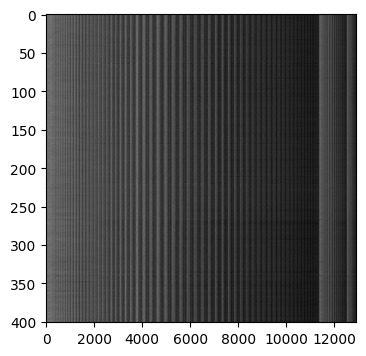

In [33]:
t_idx = [1,3,5,7,9]

sig1 = registrator.registered_frames[:,roi]
sigA = sig0 / np.mean(sig0,axis=1,keepdims=True)

plt.figure(figsize=(4,4))#, axes = plt.subplots(nrows=1, ncols=1)#, gridspec_kw={"height_ratios": [1]})
#axes[0].imshow(registrator.registered_frames[t_idx[0]],cmap='gray')
#axes[1].imshow(registrator.registered_frames[t_idx[1]],cmap='gray')

plt.imshow(sig0,cmap='gray',aspect='auto')

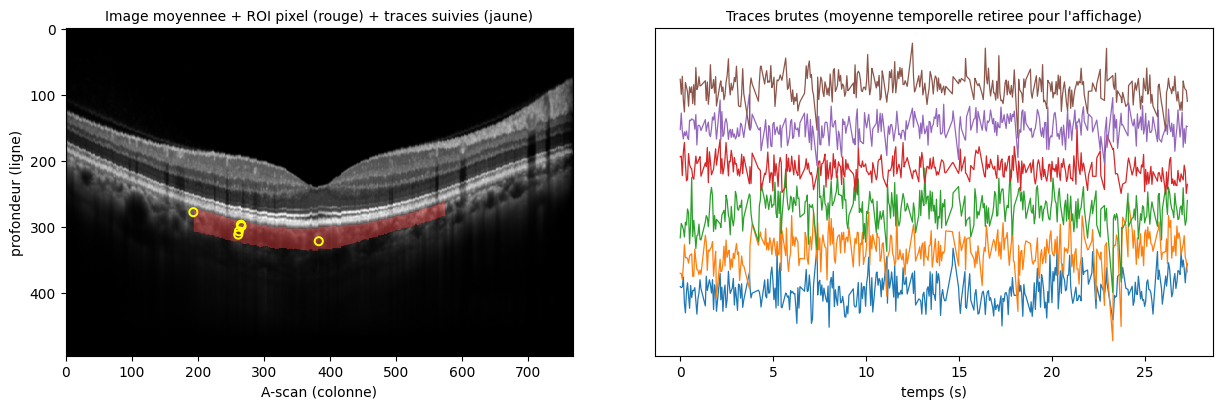

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.15, 1]})

mean_frame = registrator.registered_frames.mean(axis=0)
axes[0].imshow(mean_frame, cmap="gray")
overlay = np.zeros((*roi.shape, 4))
overlay[roi] = (1.0, 0.25, 0.25, 0.4)
axes[0].imshow(overlay)
# `raw_signal` indexe les frames par `frames[:, roi]` : les colonnes block-1 sont
# donc dans l'ordre C de `np.argwhere(roi)`. `_pool` etant trie, la position
# LOCALE d'une colonne dans le groupe block-1 donne directement son pixel.
_rc = np.argwhere(roi)[np.searchsorted(_pool, idx_plot)]
axes[0].scatter(_rc[:, 1], _rc[:, 0], s=34, facecolors="none", edgecolors="yellow", lw=1.4)
axes[0].set_title("Image moyennee + ROI pixel (rouge) + traces suivies (jaune)", fontsize=10)
axes[0].set_xlabel("A-scan (colonne)")
axes[0].set_ylabel("profondeur (ligne)")

plot_traces(axes[1], sig0, idx_plot, "Traces brutes (moyenne temporelle retiree pour l'affichage)")
fig.tight_layout()

## 1. Statistiques **par trace** (`axis=0`) -- l'heterogeneite de brillance

`mean_im = np.nanmean(sig, axis=0)` (ligne 208 de `pixel.py`) : une valeur par
trace, c'est-a-dire une **carte de brillance moyenne** de la choroide.

C'est le terme qui justifie une normalisation : si la dispersion de ces
moyennes entre pixels est tres grande devant la variance temporelle d'un pixel,
alors une SVD non centree (`DecompositionConfig(normalize=False)`, ce que fait
`compute_one_cycle_pixel_svd.py`) depensera sa premiere composante a
representer cette carte statique, pas le pouls.

Le ratio imprime ci-dessous est exactement ce diagnostic.

variance spatiale des moyennes par trace :       1.12
variance temporelle moyenne par trace    :       0.16
ratio (inter-pixels / intra-pixel)       :       7.11

moyenne par trace : 0.4 -> 6.6 (mediane 2.1)
ecart-type        : 0.11 -> 1.00 (mediane 0.37)
traces a ecart-type nul (pixels morts) : 0


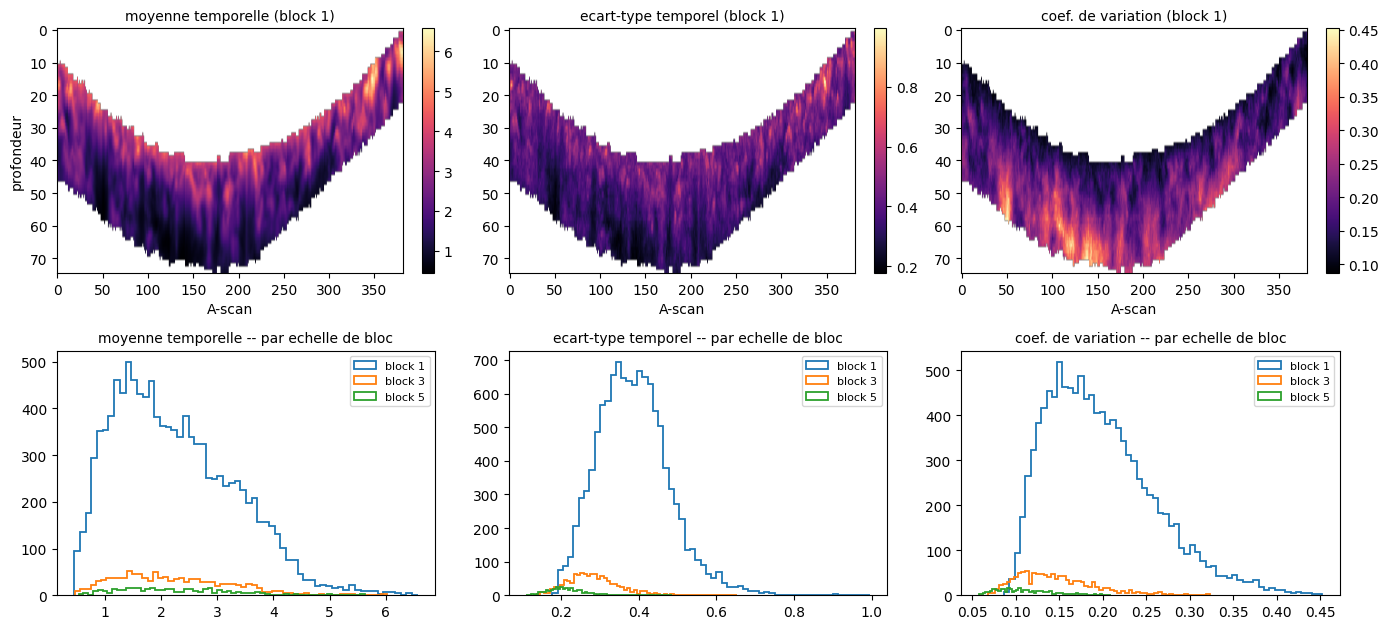

In [35]:
m_n = np.nanmean(sig0, axis=0)                       # (N,) moyenne temporelle par trace
s_n = np.nanstd(sig0, axis=0)                        # (N,) ecart-type temporel par trace
cv_n = s_n / np.maximum(m_n, 1e-6)                   # coefficient de variation

var_between = float(np.nanvar(m_n[is1]))             # variance SPATIALE des moyennes
var_within = float(np.nanmean(s_n[is1] ** 2))        # variance TEMPORELLE moyenne
print(f"variance spatiale des moyennes par trace : {var_between:10.2f}")
print(f"variance temporelle moyenne par trace    : {var_within:10.2f}")
print(f"ratio (inter-pixels / intra-pixel)       : {var_between / var_within:10.2f}")
print()
print(f"moyenne par trace : {m_n.min():.1f} -> {m_n.max():.1f} (mediane {np.median(m_n):.1f})")
print(f"ecart-type        : {s_n.min():.2f} -> {s_n.max():.2f} (mediane {np.median(s_n):.2f})")
print(f"traces a ecart-type nul (pixels morts) : {int((s_n == 0).sum())}")

fig, axes = plt.subplots(2, 3, figsize=(14, 6.4))
for ax, vals, name in zip(
    axes[0], (m_n[is1], s_n[is1], cv_n[is1]),
    ("moyenne temporelle", "ecart-type temporel", "coef. de variation"),
):
    im = ax.imshow(as_image(vals), cmap="magma", aspect="auto")
    ax.set_title(name + " (block 1)", fontsize=10)
    ax.set_xlabel("A-scan")
    fig.colorbar(im, ax=ax, fraction=0.035)
axes[0][0].set_ylabel("profondeur")

for ax, key, name in zip(
    axes[1], (m_n, s_n, cv_n),
    ("moyenne temporelle", "ecart-type temporel", "coef. de variation"),
):
    for b in BLOCK_SIZES:
        ax.hist(key[scale == b], bins=60, histtype="step", lw=1.3, label=f"block {b}")
    ax.set_title(name + " -- par echelle de bloc", fontsize=10)
    ax.legend(fontsize=8)
fig.tight_layout()

## 2. Statistique **par frame** (`axis=1`) -- le diviseur du code actuel

`np.nanmean(sig, axis=1)` (lignes 210 et 212) : une valeur par frame, la
moyenne spatiale de la ROI. C'est ce que `normalized_signal` utilise comme
diviseur.

**C'est ici que se joue la validite de la methode.** La ROI est entierement
contenue dans la choroide, et la pulsation choroidienne est en grande partie
en phase d'un pixel a l'autre : cette moyenne spatiale n'est donc pas un simple
gain d'illumination, elle contient le signal cardiaque lui-meme. La figure
ci-dessous mesure la part de sa puissance qui tombe dans la bande cardiaque.

Regle de lecture :
- pic marque a la HR -> **diviser par cette courbe soustrait le pouls**, il faut
  preferer le z-score par trace (etape 4) ;
- spectre plat / basse frequence uniquement -> le diviseur est bien une derive
  de gain, la normalisation par frame est legitime (etape 3).

moyenne par frame : 2.01 -> 2.34 (amplitude relative crete-a-crete = 14.86%)
frames a moyenne ~0 (division impossible) : 0
pic Lomb-Scargle du diviseur : 149.2 BPM
part de sa puissance dans la bande de score : 7.6%


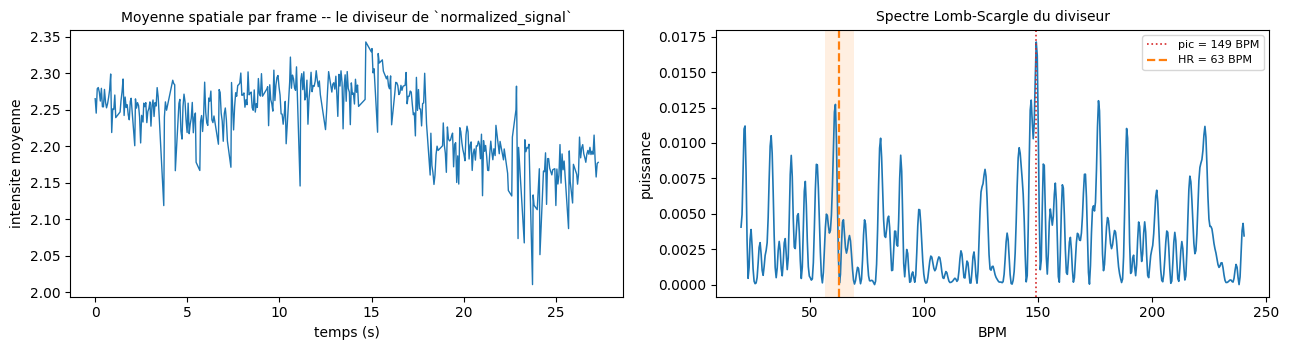

In [ ]:
g_t = np.nanmean(sig0, axis=1)
g_t = np.nanmean(sig0[:,1:30], axis=1)                 # (T,) moyenne spatiale par frame
P_g = spectrum(g_t)
frac_in_band = float(P_g[in_band].sum() / (P_g.sum() + 1e-12))
peak_bpm = float(bpm_axis[np.argmax(P_g)])

n_zero = int((np.abs(g_t) < 1e-6).sum())
print(f"moyenne par frame : {g_t.min():.2f} -> {g_t.max():.2f} "
      f"(amplitude relative crete-a-crete = {(g_t.max() - g_t.min()) / g_t.mean():.2%})")
print(f"frames a moyenne ~0 (division impossible) : {n_zero}")
print(f"pic Lomb-Scargle du diviseur : {peak_bpm:.1f} BPM")
print(f"part de sa puissance dans la bande de score : {frac_in_band:.1%}")
if np.isfinite(hr) and abs(peak_bpm - hr) <= BAND_FRAC * hr:
    print("\n  /!\\  Le diviseur pique A LA FREQUENCE CARDIAQUE : la normalisation")
    print("       par frame (etape 3) retirera une partie du signal recherche.")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(t, g_t, lw=1.0, color="C0")
axes[0].set_title("Moyenne spatiale par frame -- le diviseur de `normalized_signal`", fontsize=10)
axes[0].set_xlabel("temps (s)")
axes[0].set_ylabel("intensite moyenne")

axes[1].plot(bpm_axis, P_g, lw=1.2, color="C0")
axes[1].axvline(peak_bpm, color="C3", lw=1.2, ls=":", label=f"pic = {peak_bpm:.0f} BPM")
mark_hr(axes[1])
axes[1].set_title("Spectre Lomb-Scargle du diviseur", fontsize=10)
axes[1].set_xlabel("BPM")
axes[1].set_ylabel("puissance")
axes[1].legend(fontsize=8)
fig.tight_layout()

## 3. Variante A -- normalisation **par frame** (ce que fait le code aujourd'hui)

Transcription fidele des lignes 212-213 de `pixel.py`, en corrigeant les deux
erreurs qui empechent la methode de tourner (`mean_im` est 1-D, donc `axis=1`
leve une `AxisError` ; et rien n'est renvoye) :

```python
mu = nanmean(nanmean(sig, axis=0))      # scalaire, niveau global
sig = sig / nanmean(sig, axis=1, keepdims=True) * mu
```

Chaque frame est ramenee au meme niveau moyen `mu`. Effet attendu : supprime
une derive/scintillement global, **au prix** de la composante en phase du pouls
(cf. etape 2).

mu (niveau global) = 38.52
apres A : min=0.0  med=30.8  max=253.1
moyenne spatiale par frame apres A : 38.5163 -> 38.5332 (constante = 38.52 par construction)


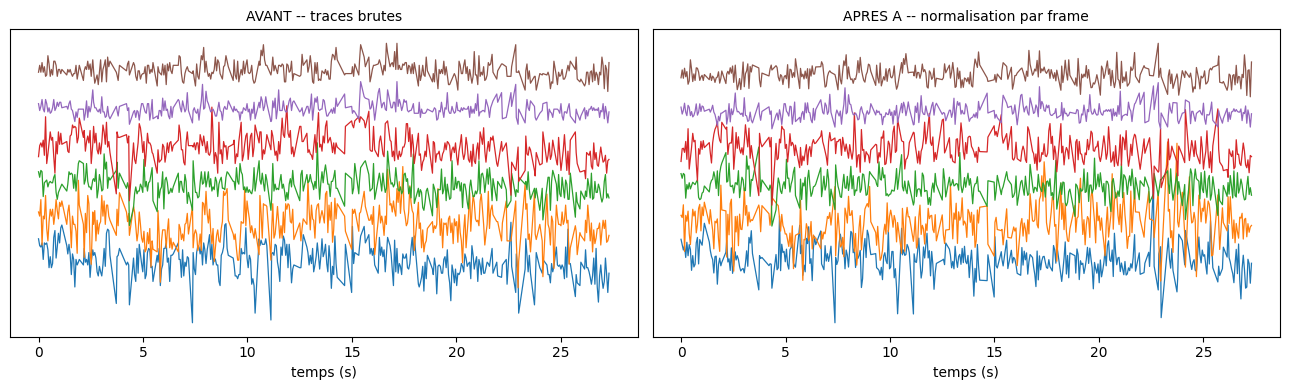

In [10]:
mu = float(np.nanmean(m_n))                    # niveau global (scalaire)
g_safe = np.where(np.abs(g_t) < 1e-6, np.nan, g_t)   # garde-fou frames noires
sig_A = (sig0 / g_safe[:, None] * mu).astype(np.float32)

print(f"mu (niveau global) = {mu:.2f}")
print(f"apres A : min={np.nanmin(sig_A):.1f}  med={np.nanmedian(sig_A):.1f}  max={np.nanmax(sig_A):.1f}")
print(f"moyenne spatiale par frame apres A : "
      f"{np.nanmean(sig_A, axis=1).min():.4f} -> {np.nanmean(sig_A, axis=1).max():.4f} "
      f"(constante = {mu:.2f} par construction)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
plot_traces(axes[0], sig0, idx_plot, "AVANT -- traces brutes")
plot_traces(axes[1], sig_A, idx_plot, "APRES A -- normalisation par frame")
fig.tight_layout()

## 4. Variante B -- **z-score par trace** (ce que dit le docstring)

`(sig - moyenne_temporelle) / ecart_type_temporel`, colonne par colonne. Chaque
pixel contribue alors a la SVD par la FORME de sa fluctuation, pas par sa
brillance ni par son amplitude absolue.

Deux consequences a garder en tete :
- le centrage rend `DecompositionConfig(normalize=False)` sans objet (les
  colonnes sont deja centrees) ;
- la reduction par `s_n` amplifie les pixels calmes -- donc aussi le bruit des
  pixels sombres. Le plancher applique a `s_n` ci-dessous evite l'explosion sur
  les pixels morts, mais c'est un parametre a discuter.

plancher d'ecart-type : 0.0785  (0 traces plafonnees)
apres B : moyenne par trace = 6.37e-07 (~0)
          ecart-type par trace : 1.000 -> 1.000


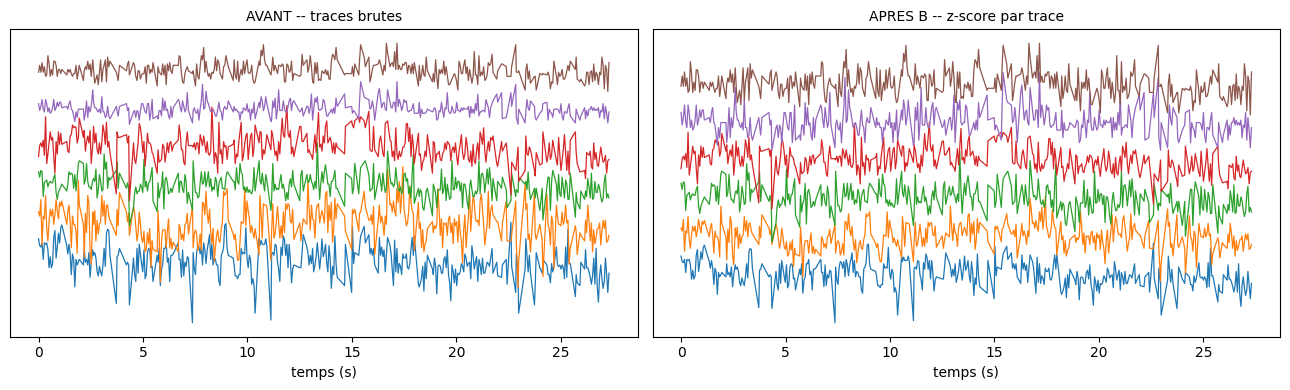

In [11]:
S_FLOOR = float(np.median(s_n)) * 1e-2         # plancher anti-explosion
s_safe = np.maximum(s_n, S_FLOOR)
n_floored = int((s_n < S_FLOOR).sum())

sig_B = ((sig0 - m_n[None, :]) / s_safe[None, :]).astype(np.float32)

print(f"plancher d'ecart-type : {S_FLOOR:.4f}  ({n_floored} traces plafonnees)")
print(f"apres B : moyenne par trace = {np.abs(np.nanmean(sig_B, axis=0)).max():.2e} (~0)")
print(f"          ecart-type par trace : {np.nanstd(sig_B, axis=0).min():.3f} "
      f"-> {np.nanstd(sig_B, axis=0).max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
plot_traces(axes[0], sig0, idx_plot, "AVANT -- traces brutes")
plot_traces(axes[1], sig_B, idx_plot, "APRES B -- z-score par trace", demean=False)
fig.tight_layout()

## 5. Variante C -- les deux enchainees

Normalisation par frame (A) PUIS z-score par trace (B). C'est la lecture la
plus charitable du code actuel : retirer d'abord la derive commune, puis mettre
tous les pixels sur un pied d'egalite.

0 brut             (401, 25777)       41 Mo
A par frame        (401, 25777)       41 Mo
B z-score trace    (401, 25777)       41 Mo
C A puis B         (401, 25777)       41 Mo


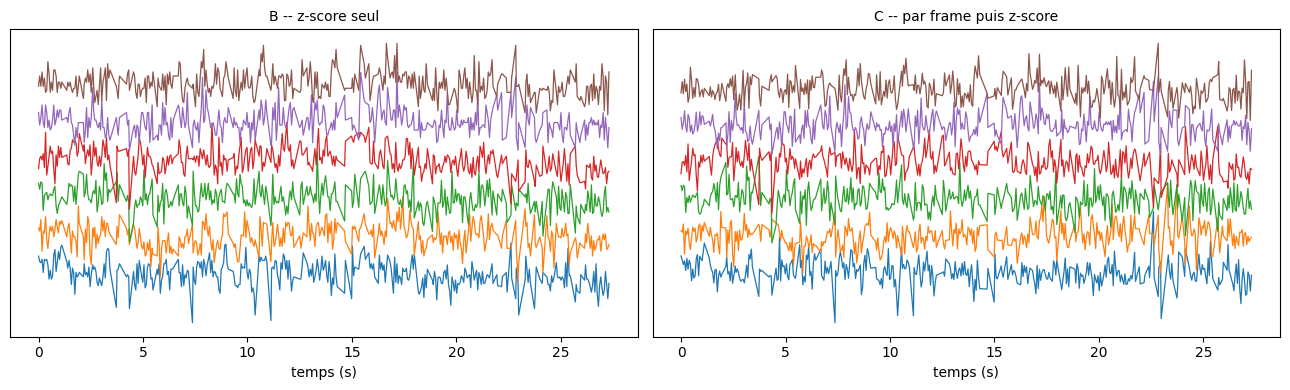

In [12]:
m_A = np.nanmean(sig_A, axis=0)
s_A = np.maximum(np.nanstd(sig_A, axis=0), S_FLOOR)
sig_C = ((sig_A - m_A[None, :]) / s_A[None, :]).astype(np.float32)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
plot_traces(axes[0], sig_B, idx_plot, "B -- z-score seul", demean=False)
plot_traces(axes[1], sig_C, idx_plot, "C -- par frame puis z-score", demean=False)
fig.tight_layout()

VARIANTS = {
    "0 brut": sig0,
    "A par frame": sig_A,
    "B z-score trace": sig_B,
    "C A puis B": sig_C,
}
for name, s in VARIANTS.items():
    print(f"{name:<18} {str(s.shape):<14} {s.nbytes / 1e6:6.0f} Mo")

## 6. Recapitulatif spectral

Puissance Lomb-Scargle **moyenne** sur les memes `N_TRACES_SPEC` traces, pour
les 4 variantes. Chaque spectre est normalise par son propre maximum : ce qui
compte n'est pas le niveau absolu (les variantes n'ont pas les memes unites)
mais le **contraste** du pic cardiaque contre le reste du spectre.

La metrique resumee est la fraction de puissance dans la bande de score
(`BAND_FRAC` autour de la HR) -- exactement ce que
`OptimizedSpectralCombination` cherchera a maximiser plus loin dans la chaine.

,pic (BPM),puissance en bande,contraste pic/median
variante,,,
0 brut,176.1,7.76%,2.1
A par frame,63.1,6.92%,1.5
B z-score trace,176.1,7.76%,2.1
C A puis B,63.1,6.92%,1.5


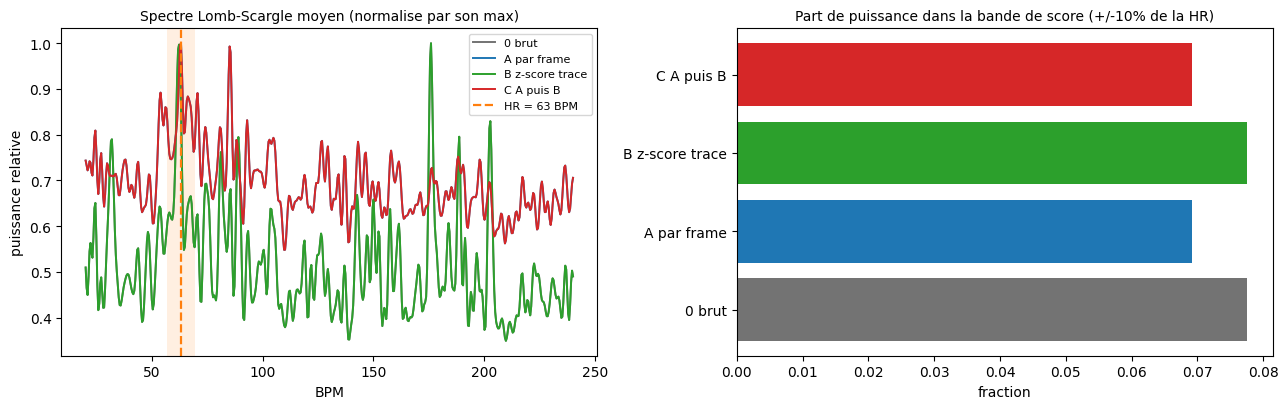

In [13]:
spectra = {name: mean_spectrum(s, idx_spec) for name, s in VARIANTS.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
rows = []
for (name, P), color in zip(spectra.items(), ["0.45", "C0", "C2", "C3"]):
    axes[0].plot(bpm_axis, P / P.max(), lw=1.4, color=color, label=name)
    frac = float(P[in_band].sum() / (P.sum() + 1e-12))
    rows.append({
        "variante": name,
        "pic (BPM)": float(bpm_axis[np.argmax(P)]),
        "puissance en bande": frac,
        "contraste pic/median": float(P.max() / (np.median(P) + 1e-12)),
    })
mark_hr(axes[0])
axes[0].set_title("Spectre Lomb-Scargle moyen (normalise par son max)", fontsize=10)
axes[0].set_xlabel("BPM")
axes[0].set_ylabel("puissance relative")
axes[0].legend(fontsize=8)

tab = pd.DataFrame(rows).set_index("variante")
axes[1].barh(tab.index, tab["puissance en bande"], color=["0.45", "C0", "C2", "C3"])
axes[1].set_title(f"Part de puissance dans la bande de score (+/-{BAND_FRAC:.0%} de la HR)", fontsize=10)
axes[1].set_xlabel("fraction")
fig.tight_layout()

display(tab.style.format({"pic (BPM)": "{:.1f}", "puissance en bande": "{:.2%}",
                          "contraste pic/median": "{:.1f}"}))

## 7. Effet en aval : la SVD

C'est le seul test qui compte vraiment, puisque `compute_one_cycle_pixel_svd.py`
ne consomme jamais les traces directement : il leur applique une SVD tronquee
(`normalize=False`), puis `OptimizedSpectralCombination` selectionne les
composantes dont le pic Lomb-Scargle tombe pres de la frequence cardiaque.

Pour chaque variante on regarde :
- combien de composantes sur `N_SVD_COMPONENTS` piquent dans la bande de score
  (= le vivier de candidates pour l'optimisation) ;
- la meilleure puissance en bande atteinte par une composante.

Cellule la plus lourde du notebook (4 SVD tronquees + 4 x `N_SVD_COMPONENTS`
periodogrammes).

In [14]:
svd_results = {}
rows = []
for name, s in VARIANTS.items():
    comps, _mix = project_into_separable_components(
        np.nan_to_num(s, nan=0.0).astype(np.float64),
        method="svd",
        n_components=N_SVD_COMPONENTS,
        normalize=False,          # comme compute_one_cycle_pixel_svd.py
        random_state=0,
    )
    P = np.stack([spectrum(comps[:, k]) for k in range(comps.shape[1])], axis=1)
    peak_bpm_k = bpm_axis[P.argmax(axis=0)]
    in_band_k = in_band[P.argmax(axis=0)]
    frac_k = P[in_band].sum(axis=0) / (P.sum(axis=0) + 1e-12)
    svd_results[name] = (comps, P, in_band_k)
    rows.append({
        "variante": name,
        "composantes en bande": int(in_band_k.sum()),
        "1re en bande": int(np.argmax(in_band_k)) if in_band_k.any() else -1,
        "meilleure puiss. en bande": float(frac_k.max()),
        "pic de la comp. #0": float(peak_bpm_k[0]),
    })

tab_svd = pd.DataFrame(rows).set_index("variante")
display(tab_svd.style.format({"meilleure puiss. en bande": "{:.2%}",
                              "pic de la comp. #0": "{:.1f}"}))

,composantes en bande,1re en bande,meilleure puiss. en bande,pic de la comp. #0
variante,,,,
0 brut,7,4,19.82%,176.1
A par frame,7,4,20.09%,176.1
B z-score trace,9,2,23.22%,176.1
C A puis B,6,3,16.56%,85.5


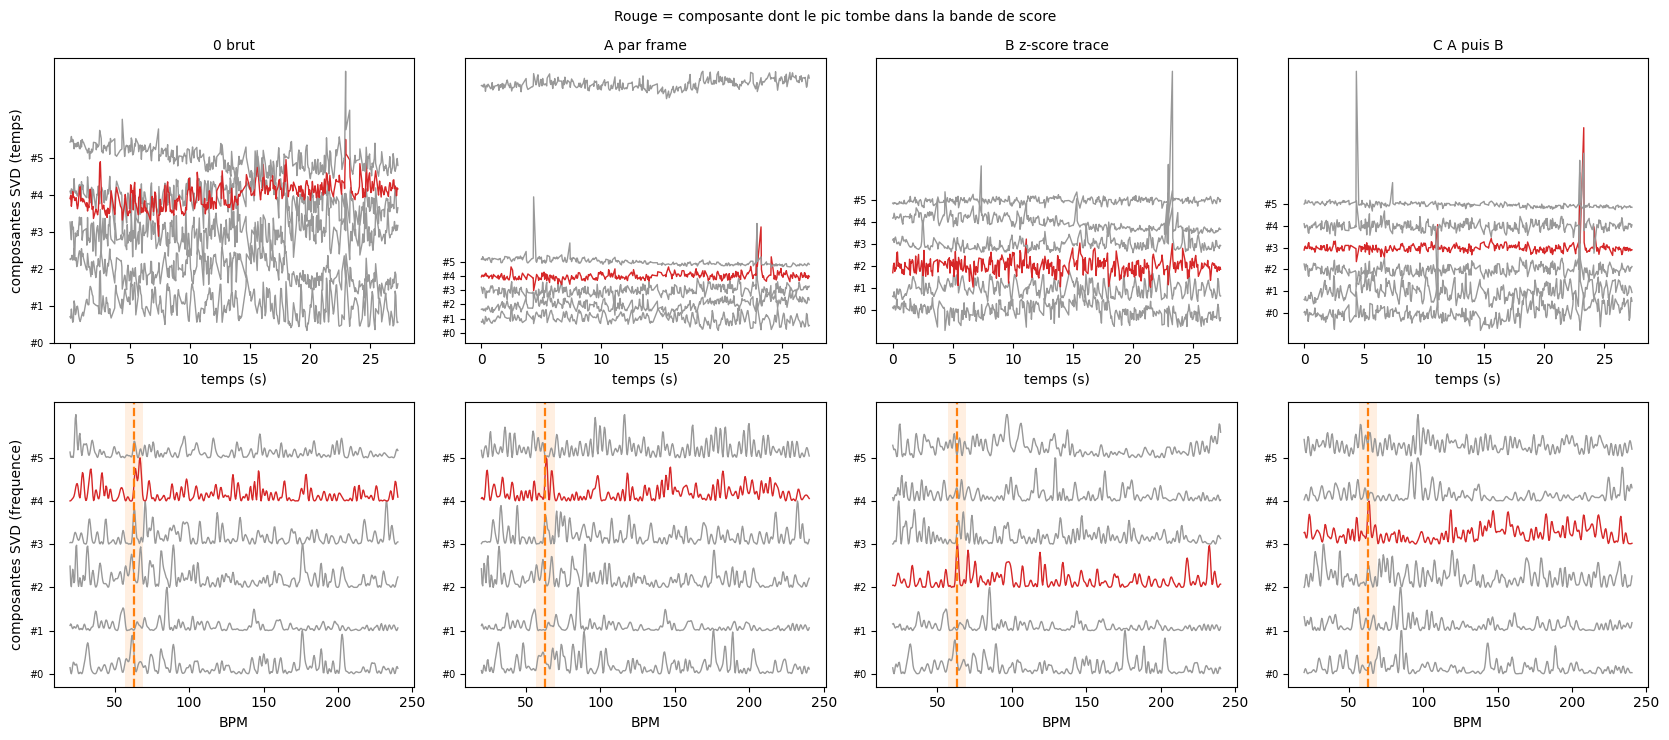

In [15]:
K_SHOW = 6
fig, axes = plt.subplots(2, len(VARIANTS), figsize=(4.2 * len(VARIANTS), 7.5), sharex="row")
for j, (name, (comps, P, in_band_k)) in enumerate(svd_results.items()):
    step = 3.0 * np.median(comps[:, :K_SHOW].std(axis=0)) + 1e-9
    for k in range(K_SHOW):
        color = "C3" if in_band_k[k] else "0.6"
        axes[0][j].plot(t, comps[:, k] / (comps[:, k].std() + 1e-9) * step / 3 + k * step,
                        lw=1.0, color=color)
        axes[1][j].plot(bpm_axis, P[:, k] / (P[:, k].max() + 1e-12) + k, lw=1.0, color=color)
    axes[0][j].set_title(name, fontsize=10)
    axes[0][j].set_xlabel("temps (s)")
    axes[0][j].set_yticks(np.arange(K_SHOW) * step)
    axes[0][j].set_yticklabels([f"#{k}" for k in range(K_SHOW)], fontsize=7)
    mark_hr(axes[1][j])
    axes[1][j].set_xlabel("BPM")
    axes[1][j].set_yticks(np.arange(K_SHOW))
    axes[1][j].set_yticklabels([f"#{k}" for k in range(K_SHOW)], fontsize=7)
axes[0][0].set_ylabel("composantes SVD (temps)")
axes[1][0].set_ylabel("composantes SVD (frequence)")
fig.suptitle("Rouge = composante dont le pic tombe dans la bande de score", fontsize=10)
fig.tight_layout()

## 8. Etat actuel de `PixelTraceSource.normalized_signal()`

La cellule suivante appelle la vraie methode, pour comparaison avec les
variantes ci-dessus. En l'etat (`pixel.py:203-213`) elle ne peut pas aboutir :

1. `mean_im = np.nanmean(sig, axis=0)` est **1-D** `(N,)`, donc
   `np.nanmean(mean_im, axis=1)` a la ligne suivante leve une `AxisError` ;
2. la methode ne **renvoie rien** (`-> None`) et travaille sur le tableau frais
   rendu par `raw_signal()` -- le "in-place" du docstring ne remonte nulle part,
   ni vers `signal`, ni vers `interpolated_signal`, ni vers la SVD ;
3. le docstring annonce un z-score par trace (variante B) alors que le corps
   fait une normalisation par frame (variante A) : ce sont deux operations
   differentes, sur deux axes differents.

A noter aussi, juste en dessous : `filtered_signal` est redefinie ici comme une
**methode**, alors que la classe de base l'expose comme une **property**
(`base.py:217`). `AbstractUniformTraceSource.compute()` fait
`filtered = self.filtered_signal` puis `np.isnan(filtered)` -> il recevra un
objet `bound method` et levera un `TypeError`. Le chemin `PixelTraceSource ->
Traces` est donc casse tant que ce n'est pas soit supprime, soit decore
`@property`.

Une fois la methode reecrite, relancer cette cellule : elle recalcule les
memes metriques que l'etape 6 sur sa sortie.

In [16]:
try:
    out = source.normalized_signal()
except Exception as exc:
    print(f"normalized_signal() a leve : {type(exc).__name__}: {exc}")
    out = None

if out is None:
    print("\n-> rien n'est renvoye : la normalisation ne remonte pas jusqu'aux traces.")
else:
    out = np.asarray(out, dtype=np.float32)
    P = mean_spectrum(out, idx_spec)
    print(f"\nsortie : {out.shape} {out.dtype}")
    print(f"moyenne par trace : {np.abs(np.nanmean(out, axis=0)).max():.3e}")
    print(f"ecart-type par trace : {np.nanstd(out, axis=0).min():.3f} "
          f"-> {np.nanstd(out, axis=0).max():.3f}")
    print(f"pic du spectre moyen : {bpm_axis[np.argmax(P)]:.1f} BPM")
    print(f"puissance en bande : {P[in_band].sum() / (P.sum() + 1e-12):.2%}")
    for name, ref in VARIANTS.items():
        d = float(np.nanmax(np.abs(out - ref))) if out.shape == ref.shape else np.nan
        print(f"  ecart max vs {name:<18} : {d:.3e}")

    fig, ax = plt.subplots(figsize=(7, 3.6))
    for (name, Pv), color in zip(spectra.items(), ["0.45", "C0", "C2", "C3"]):
        ax.plot(bpm_axis, Pv / Pv.max(), lw=1.0, color=color, alpha=0.6, label=name)
    ax.plot(bpm_axis, P / P.max(), lw=2.0, color="k", label="normalized_signal()")
    mark_hr(ax)
    ax.set_xlabel("BPM")
    ax.set_ylabel("puissance relative")
    ax.legend(fontsize=8)
    fig.tight_layout()

normalized_signal() a leve : AxisError: axis 1 is out of bounds for array of dimension 1

-> rien n'est renvoye : la normalisation ne remonte pas jusqu'aux traces.
